import libraries

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

load clean data

In [8]:
project_dir = Path.cwd().parent
file_path = project_dir / "data" / "cleaned" / "cleaned_retail_sales.csv"

df = pd.read_csv("../data/raw/retail_sales.csv")
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,Segment,Region,State,Category,SubCategory,Product,UnitPrice,Quantity,Discount,Sales,Cost,Profit,PaymentMethod,ShipMode
0,ORD-00001,2024-07-08,C0178,Isha Khan,Corporate,South,North Carolina,Office Supplies,Writing,Desk Organizer,28,7,0.0,196.0,80.36,115.64,Debit Card,Standard Class
1,ORD-00002,2024-03-26,C0137,Lucas Miller,Home Office,South,Georgia,Office Supplies,Paper,Copy Paper,15,8,0.0,120.0,42.00,78.00,UPI,Second Class
2,ORD-00003,2024-08-31,C0033,Liam Patel,Consumer,South,Georgia,Technology,Accessories,Laptop Sleeve,35,5,0.1,157.5,66.50,91.00,UPI,Standard Class
3,ORD-00004,2025-10-13,C0054,Liam Davis,Consumer,East,Massachusetts,Office Supplies,Paper,Notebook Set,22,3,0.2,52.8,26.40,26.40,Debit Card,First Class
4,ORD-00005,2025-08-15,C0019,Aarav Patel,Home Office,Central,Texas,Furniture,Tables,Coffee Table,149,3,0.0,447.0,232.44,214.56,UPI,Same Day


check data

In [9]:
print(df.shape)
print(df.info())
df.describe()

(755, 18)
<class 'pandas.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        755 non-null    str           
 1   OrderDate      755 non-null    datetime64[us]
 2   CustomerID     755 non-null    str           
 3   CustomerName   755 non-null    str           
 4   Segment        755 non-null    str           
 5   Region         755 non-null    str           
 6   State          755 non-null    str           
 7   Category       755 non-null    str           
 8   SubCategory    755 non-null    str           
 9   Product        755 non-null    str           
 10  UnitPrice      755 non-null    int64         
 11  Quantity       755 non-null    int64         
 12  Discount       755 non-null    float64       
 13  Sales          755 non-null    float64       
 14  Cost           755 non-null    float64       
 15  Profit         755 non-n

,OrderDate,UnitPrice,Quantity,Discount,Sales,Cost,Profit
count,755,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000
mean,2024-12-18 05:47:07.549668,210.143046,4.364238,0.072384,680.483179,428.070252,252.412927
min,2024-01-01 00:00:00,12.000000,1.000000,0.000000,12.000000,3.600000,8.250000
25%,2024-06-19 00:00:00,28.000000,2.000000,0.000000,127.750000,53.100000,66.000000
50%,2024-12-06 00:00:00,129.000000,4.000000,0.050000,279.000000,144.420000,129.800000
75%,2025-06-22 12:00:00,249.000000,5.000000,0.150000,848.550000,567.150000,302.210000
max,2025-12-31 00:00:00,1099.000000,12.000000,0.200000,5495.000000,3626.700000,1868.300000
std,NaN,268.660649,2.813579,0.075137,930.903724,640.095905,313.952990


Create useful data column

In [10]:
df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month_name()
df["MonthNumber"] = df["OrderDate"].dt.month
df["YearMonth"] = df["OrderDate"].dt.to_period("M").astype(str)

Calculate KPIs

In [11]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["OrderID"].nunique()
total_customers = df["CustomerID"].nunique()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $513,764.80
Total Profit: $190,571.76
Total Orders: 750
Total Customers: 176
Profit Margin: 37.09%


Monthly sales trend


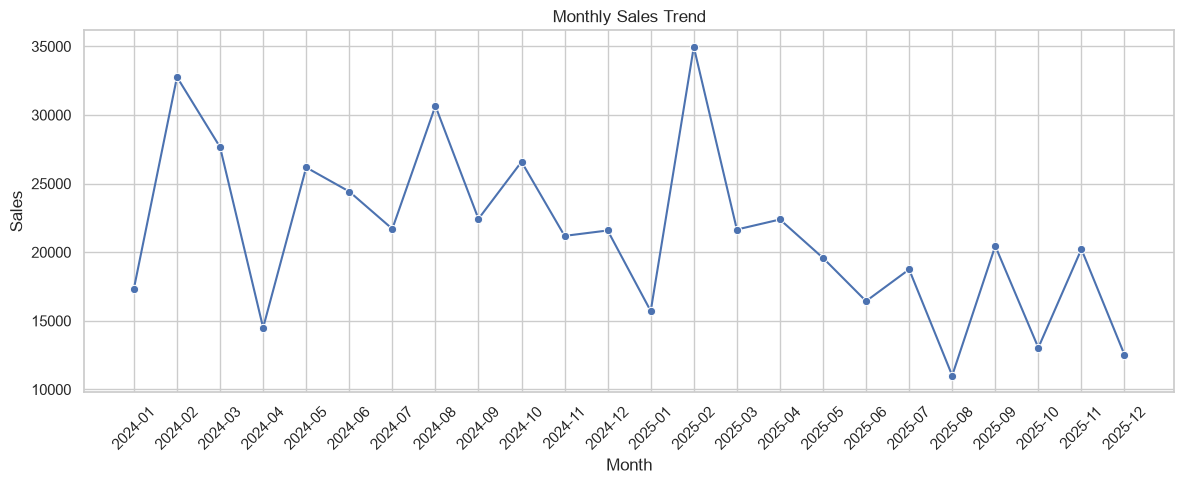

In [12]:
monthly_sales = (
    df.groupby("YearMonth", as_index=False)["Sales"]
    .sum()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="YearMonth", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales and profit by catogery

In [13]:
category_summary = (
    df.groupby("Category", as_index=False)[["Sales", "Profit"]]
    .sum()
)

category_summary

,Category,Sales,Profit
0,Furniture,153511.50,54697.64
1,Office Supplies,78718.55,34666.38
2,Technology,281534.75,101207.74


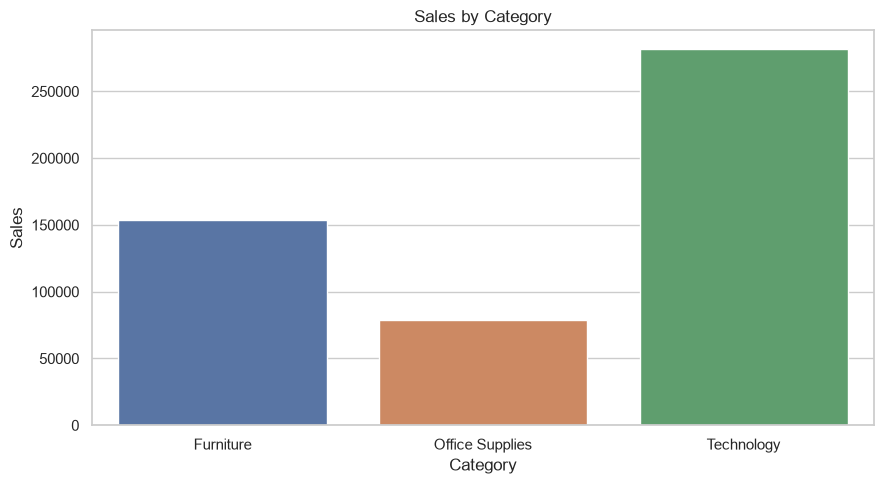

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=category_summary, x="Category", y="Sales", hue="Category", legend=False)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Sales by region

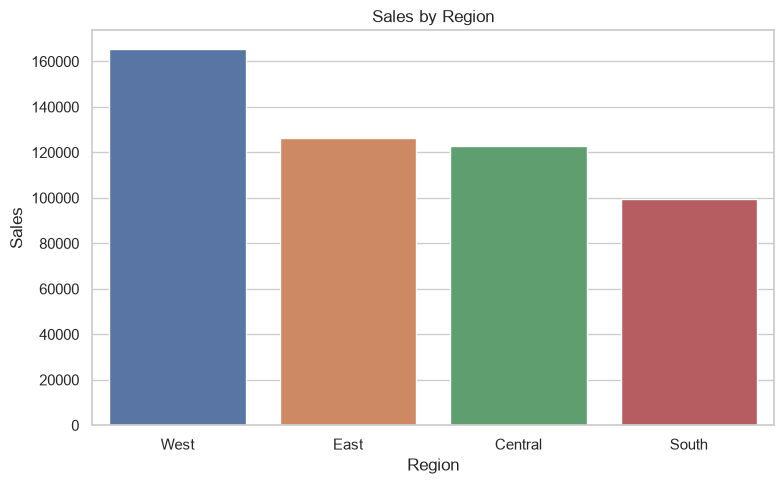

In [15]:
region_sales = (
    df.groupby("Region", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, x="Region", y="Sales", hue="Region", legend=False)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Top 10 customer

In [16]:
top_customers = (
    df.groupby(["CustomerID", "CustomerName"], as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_customers

,CustomerID,CustomerName,Sales
174,C0179,Noah Patel,13631.00
50,C0052,Mia Sharma,12902.80
115,C0119,Kavya Khan,10147.20
123,C0127,Mia Khan,9283.30
85,C0089,Kavya Garcia,8690.05
108,C0112,Ethan Patel,8356.85
55,C0058,Sara Miller,7900.00
51,C0053,Kavya Sharma,7444.80
47,C0049,Kavya Davis,7368.45
118,C0122,Sara Brown,7190.85


Discount versus profit

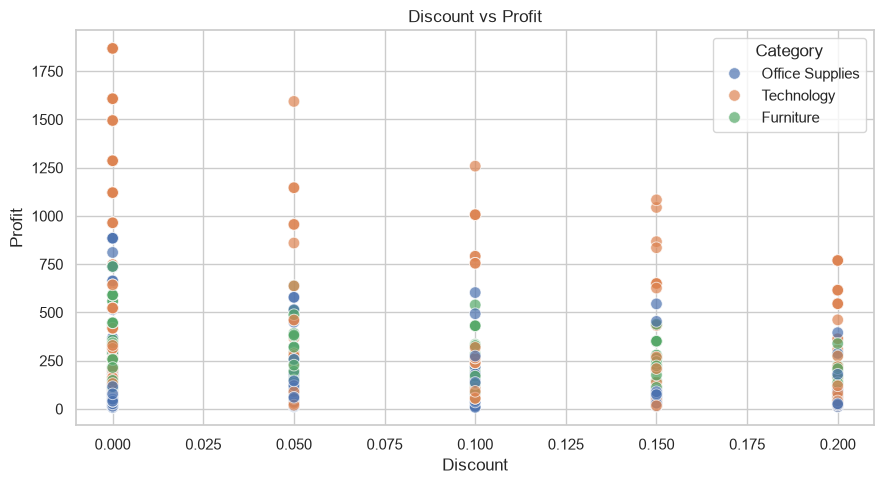

In [17]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.7,
    s=70
)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()